# 04 · 過擬合控制與 early stopping

樹種太少會欠擬合、太多會過擬合。手動試很煩——**early stopping** 讓 XGBoost 自己盯著驗證集，一旦不再進步就停。這堂課也順道認識幾個關鍵的正則化旋鈕。

## 學習目標

- 用驗證集畫出「訓練 vs 驗證」的學習曲線，看見過擬合
- 用 `early_stopping_rounds` 自動挑最佳樹數
- 認識 `subsample` / `colsample_bytree` / `reg_lambda` 等抑制過擬合的參數

## 1. 先把資料切成三份

調參時要用**驗證集**，測試集留到最後。

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

X, y = load_breast_cancer(return_X_y=True)
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp)
print("train/val/test:", X_train.shape[0], X_val.shape[0], X_test.shape[0])

train/val/test: 341 114 114


## 2. Early stopping：讓模型自己喊停

設一個很大的 `n_estimators`，再給 `early_stopping_rounds`——連續這麼多輪驗證分數沒進步，就停在最佳點。

In [2]:
model = XGBClassifier(
    n_estimators=1000, learning_rate=0.1, max_depth=3,
    eval_metric="logloss", early_stopping_rounds=20, random_state=42,
)
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)
print(f"設定上限 1000 棵，實際最佳停在第 {model.best_iteration} 棵")
print(f"測試準確率：{model.score(X_test, y_test):.3f}")

設定上限 1000 棵，實際最佳停在第 96 棵
測試準確率：0.956


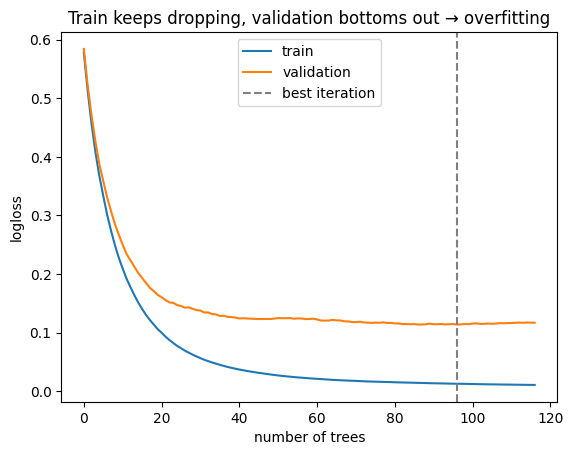

In [3]:
import matplotlib.pyplot as plt

# 畫出訓練 vs 驗證的 logloss 曲線
results = model.evals_result()
plt.plot(results["validation_0"]["logloss"], label="train")
plt.plot(results["validation_1"]["logloss"], label="validation")
plt.axvline(model.best_iteration, color="gray", ls="--", label="best iteration")
plt.xlabel("number of trees"); plt.ylabel("logloss"); plt.legend()
plt.title("Train keeps dropping, validation bottoms out → overfitting")
plt.show()

經典的過擬合長相：訓練 logloss 一路向下，驗證 logloss 觸底後反彈。early stopping 幫你停在驗證的谷底。

## 3. 其他正則化旋鈕

| 參數 | 做什麼 |
| --- | --- |
| `subsample` | 每棵樹只用部分資料（如 0.8）→ 增加隨機性、抗過擬合 |
| `colsample_bytree` | 每棵樹只用部分特徵 |
| `reg_lambda` / `reg_alpha` | L2 / L1 正則化，懲罰過大的葉子權重 |
| `min_child_weight` | 葉子最少要有多少樣本，越大越保守 |

## 小結

- 切出**驗證集**，用學習曲線就能看見過擬合。
- `early_stopping_rounds` + `eval_set` 自動挑最佳樹數，`best_iteration` 拿得到。
- `subsample` / `colsample_bytree` / `reg_lambda` 等是抑制過擬合的常用旋鈕。

## 練習

1. 把 `learning_rate` 調到 0.01，`best_iteration` 會變大還是變小？為什麼？
2. 加上 `subsample=0.7, colsample_bytree=0.7`，驗證曲線的谷底有變嗎？

下一課，系統性地**調參**。